In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import pandas
data = pandas.read_csv("churn.csv")

data = data.drop(columns = [ 'customerID' ])
data = data[data["TotalCharges"] != ' ']
data["TotalCharges"] = data["TotalCharges"].astype(float)

data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [3]:
data.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [4]:
import sklearn.model_selection

X = data.drop(columns = [ "Churn" ])
y = (data["Churn"] == "Yes").to_numpy()

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size = 0.1, stratify = y, random_state = 1
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6328, 19), (704, 19), (6328,), (704,))

In [5]:
numeric = [ "SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges" ]
categorical = list(set(X_train.columns) - set(numeric))

len(numeric), len(categorical), len(X_train.columns)

(4, 15, 19)

In [6]:
import sklearn.compose
import sklearn.preprocessing

ct = sklearn.compose.ColumnTransformer(
    transformers=[
        ("numeric", 'passthrough', numeric),
        ("categorical", sklearn.preprocessing.OneHotEncoder(drop = 'first'), categorical)
    ]
)
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

X_train.shape, X_test.shape

((6328, 30), (704, 30))

In [7]:
y_train.shape, y_test.shape

((6328,), (704,))

In [8]:
import sklearn.preprocessing

ss = sklearn.preprocessing.StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

In [9]:
import tqdm
from utils import estimate_quality

import xgboost
import catboost
import sklearn.svm
import sklearn.tree
import sklearn.ensemble
import sklearn.neighbors
import sklearn.naive_bayes
import sklearn.linear_model
import sklearn.neural_network

models = [
    # neighbors
    sklearn.neighbors.KNeighborsClassifier(n_jobs = -1, n_neighbors = 50),
    sklearn.neighbors.RadiusNeighborsClassifier(n_jobs = -1, radius = 7),

    # naive_bayes
    sklearn.naive_bayes.BernoulliNB(),
    sklearn.naive_bayes.GaussianNB(),

    # linear_model
    sklearn.linear_model.LogisticRegression(),
    
    # svm
    sklearn.svm.SVC(probability = True),
    sklearn.svm.NuSVC(probability = True),
    
    # tree
    sklearn.tree.DecisionTreeClassifier(),
    sklearn.tree.ExtraTreeClassifier(),

    # ensemble
    sklearn.ensemble.BaggingClassifier(n_estimators = 100, random_state = 42, n_jobs = -1),
    sklearn.ensemble.AdaBoostClassifier(n_estimators = 500, algorithm = 'SAMME', random_state = 42),
    sklearn.ensemble.ExtraTreesClassifier(n_estimators = 500, random_state = 42, n_jobs = -1),
    sklearn.ensemble.RandomForestClassifier(n_estimators = 1000, random_state = 42, n_jobs = -1),
    sklearn.ensemble.GradientBoostingClassifier(n_estimators = 1000, random_state = 42),
    sklearn.ensemble.HistGradientBoostingClassifier(random_state = 42),

    # neural_network
    sklearn.neural_network.MLPClassifier(max_iter = 2000),
    
    # xgboost
    xgboost.XGBClassifier(n_jobs = -1, n_estimators = 50, max_depth = 4, device = 'gpu'),

    # catboost
    catboost.CatBoostClassifier(
        iterations = 600,
        depth = 4,
        random_seed = 42,
        loss_function = 'MultiClass',
        devices = '0-3',
        task_type = 'GPU',
        verbose = False
    ),
]

results = []
for model in tqdm.tqdm(models):
    model.fit(X_train_scaled, y_train)
    metrics = estimate_quality(model.predict_proba(X_test_scaled), y_test)
    results.append({ 'model': str(model), **metrics })
pandas.DataFrame(results)

 89%|████████▉ | 16/18 [00:45<00:14,  7.20s/it]d:\Programs\Programming\Python\lib\site-packages\xgboost\core.py:158: UserWarning: [01:22:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)
100%|██████████| 18/18 [00:48<00:00,  2.67s/it]


,model,Accuracy,Precision,Recall,AUC-ROC,F1-score,True Positive,True Negative,False Positive,False Negative,True Negative Rate (Specificity),Negative Predictive Value,False Positive Rate,False Discovery Rate
0,"KNeighborsClassifier(n_jobs=-1, n_neighbors=50)",0.802557,0.641176,0.582888,0.800805,0.610644,109,456,61,78,0.882012,0.853933,0.117988,0.358824
1,"RadiusNeighborsClassifier(n_jobs=-1, radius=7)",0.734375,0.000000,0.000000,0.802361,0.000000,0,517,0,187,1.000000,0.734375,0.000000,0.000000
2,BernoulliNB(),0.707386,0.468013,0.743316,0.802387,0.574380,139,359,158,48,0.694391,0.882064,0.305609,0.531987
3,GaussianNB(),0.640625,0.412234,0.828877,0.809659,0.550622,155,296,221,32,0.572534,0.902439,0.427466,0.587766
4,LogisticRegression(),0.799716,0.647436,0.540107,0.822836,0.588921,101,462,55,86,0.893617,0.843066,0.106383,0.352564
5,SVC(probability=True),0.801136,0.671533,0.491979,0.769474,0.567901,92,472,45,95,0.912959,0.832451,0.087041,0.328467
6,NuSVC(probability=True),0.802557,0.690476,0.465241,0.784648,0.555911,87,478,39,100,0.924565,0.826990,0.075435,0.309524
7,DecisionTreeClassifier(),0.734375,0.500000,0.540107,0.671485,0.519280,101,416,101,86,0.804642,0.828685,0.195358,0.500000
8,ExtraTreeClassifier(),0.728693,0.489130,0.481283,0.649733,0.485175,90,423,94,97,0.818182,0.813462,0.181818,0.510870
9,"BaggingClassifier(n_estimators=100, n_jobs=-1,...",0.781250,0.603774,0.513369,0.795607,0.554913,96,454,63,91,0.878143,0.833028,0.121857,0.396226


In [10]:
import numpy
X_train_df = pandas.DataFrame(X_train.copy(), columns = ct.get_feature_names_out())
tenure_thresholds = numpy.unique(X_train_df["numeric__tenure"])
total_charges_thresholds = numpy.unique(X_train_df["numeric__TotalCharges"])[::25]
monthly_charges_thresholds = numpy.unique(X_train_df["numeric__MonthlyCharges"])[::10]

In [11]:
X_train_bin = pandas.DataFrame(X_train.copy(), columns = ct.get_feature_names_out())

for threshold in tenure_thresholds:
    X_train_bin[f"Tenture_lt_{threshold}"] = X_train_bin["numeric__tenure"] <= threshold
    X_train_bin[f"Tenture_gt_{threshold}"] = X_train_bin["numeric__tenure"] >= threshold
    
for threshold in total_charges_thresholds:
    X_train_bin[f"TotalCharges_lt_{threshold}"] = X_train_bin["numeric__TotalCharges"] <= threshold
    X_train_bin[f"TotalCharges_gt_{threshold}"] = X_train_bin["numeric__TotalCharges"] >= threshold
    
for threshold in monthly_charges_thresholds:
    X_train_bin[f"MonthlyCharges_lt_{threshold}"] = X_train_bin["numeric__MonthlyCharges"] <= threshold
    X_train_bin[f"MonthlyCharges_gt_{threshold}"] = X_train_bin["numeric__MonthlyCharges"] >= threshold

X_train_bin = X_train_bin.drop(columns = ["numeric__tenure"])
X_train_bin = X_train_bin.drop(columns = ["numeric__MonthlyCharges"])
X_train_bin = X_train_bin.drop(columns = ["numeric__TotalCharges"])

X_train_bin

C:\Users\TTPO100AJIEX\AppData\Local\Temp\ipykernel_14052\3977778007.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train_bin[f"Tenture_gt_{threshold}"] = X_train_bin["numeric__tenure"] >= threshold
C:\Users\TTPO100AJIEX\AppData\Local\Temp\ipykernel_14052\3977778007.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train_bin[f"Tenture_lt_{threshold}"] = X_train_bin["numeric__tenure"] <= threshold
C:\Users\TTPO100AJIEX\AppData\Local\Temp\ipykernel_14052\3977778007.py:5: PerformanceWarning: DataFrame is highly fragmented

,numeric__SeniorCitizen,categorical__InternetService_Fiber optic,categorical__InternetService_No,categorical__gender_Male,categorical__StreamingTV_No internet service,categorical__StreamingTV_Yes,categorical__Contract_One year,categorical__Contract_Two year,categorical__StreamingMovies_No internet service,categorical__StreamingMovies_Yes,...,MonthlyCharges_lt_114.55,MonthlyCharges_gt_114.55,MonthlyCharges_lt_115.1,MonthlyCharges_gt_115.1,MonthlyCharges_lt_116.0,MonthlyCharges_gt_116.0,MonthlyCharges_lt_116.55,MonthlyCharges_gt_116.55,MonthlyCharges_lt_117.5,MonthlyCharges_gt_117.5
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,True,False,True,False,True,False,True,False,True,False
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,True,False,True,False,True,False,True,False,True,False
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,True,False,True,False,True,False,True,False,True,False
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,True,False,True,False,True,False,True,False,True,False
4,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,False,True,True,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6323,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,True,False,True,False,True,False,True,False,True,False
6324,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,True,False,True,False,True,False,True,False,True,False
6325,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,True,False,True,False,True,False,True,False,True,False
6326,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,True,False,True,False,True,False,True,False,True,False


In [12]:
X_train_bin[y_train == True].astype(int).to_csv("X_train_bin.csv", index = False)

In [46]:
X_test_bin = pandas.DataFrame(X_test.copy(), columns = ct.get_feature_names_out())

for threshold in tenure_thresholds:
    X_test_bin[f"Tenture_lt_{threshold}"] = X_test_bin["numeric__tenure"] <= threshold
    X_test_bin[f"Tenture_gt_{threshold}"] = X_test_bin["numeric__tenure"] >= threshold
    
for threshold in total_charges_thresholds:
    X_test_bin[f"TotalCharges_lt_{threshold}"] = X_test_bin["numeric__TotalCharges"] <= threshold
    X_test_bin[f"TotalCharges_gt_{threshold}"] = X_test_bin["numeric__TotalCharges"] >= threshold
    
for threshold in monthly_charges_thresholds:
    X_test_bin[f"MonthlyCharges_lt_{threshold}"] = X_test_bin["numeric__MonthlyCharges"] <= threshold
    X_test_bin[f"MonthlyCharges_gt_{threshold}"] = X_test_bin["numeric__MonthlyCharges"] >= threshold

X_test_bin = X_test_bin.drop(columns = ["numeric__tenure"])
X_test_bin = X_test_bin.drop(columns = ["numeric__MonthlyCharges"])
X_test_bin = X_test_bin.drop(columns = ["numeric__TotalCharges"])

X_test_bin

C:\Users\TTPO100AJIEX\AppData\Local\Temp\ipykernel_5232\230719952.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test_bin[f"Tenture_gt_{threshold}"] = X_test_bin["numeric__tenure"] >= threshold
C:\Users\TTPO100AJIEX\AppData\Local\Temp\ipykernel_5232\230719952.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test_bin[f"Tenture_lt_{threshold}"] = X_test_bin["numeric__tenure"] <= threshold
C:\Users\TTPO100AJIEX\AppData\Local\Temp\ipykernel_5232\230719952.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is

,numeric__SeniorCitizen,categorical__PhoneService_Yes,categorical__gender_Male,categorical__Partner_Yes,categorical__InternetService_Fiber optic,categorical__InternetService_No,categorical__PaperlessBilling_Yes,categorical__TechSupport_No internet service,categorical__TechSupport_Yes,categorical__Contract_One year,...,MonthlyCharges_lt_114.55,MonthlyCharges_gt_114.55,MonthlyCharges_lt_115.1,MonthlyCharges_gt_115.1,MonthlyCharges_lt_116.0,MonthlyCharges_gt_116.0,MonthlyCharges_lt_116.55,MonthlyCharges_gt_116.55,MonthlyCharges_lt_117.5,MonthlyCharges_gt_117.5
0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,True,False,True,False,True,False,True,False,True,False
1,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,True,False,True,False,True,False,True,False,True,False
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,True,False,True,False,True,False,True,False,True,False
3,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,True,False,True,False,True,False,True,False,True,False
4,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,True,False,True,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,True,False,True,False,True,False,True,False,True,False
700,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,True,False,True,False,True,False,True,False,True,False
701,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,...,True,False,True,False,True,False,True,False,True,False
702,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,True,False,True,False,True,False,True,False,True,False


In [47]:
import typing

import tqdm
import joblib
import numpy

class LazyClassifierFCA:
    def __init__(self):
        self.X_test = None
        self.y_train = None

    def fit(self, X_train: numpy.ndarray, y_train: numpy.ndarray) -> None:
        self.X_train = X_train
        self.y_train = y_train
        
        self.X_train_positive = self.X_train[y_train == 1]
        self.X_train_negative = self.X_train[y_train == 0]
        
    def classify_sample(self, sample: numpy.ndarray) -> typing.Any:
        
        positive_classifiers = 0
        negative_classifiers = 0
        
        # Function to check if intersection with a train sample is a positive classifier
        def is_positive_classifier(intersection):
            # Find samples in X_train_positive that contain the intersection
            num_positive = ((self.X_train_positive | ~intersection) == True).all(axis=1).sum()
            num_negative = ((self.X_train_negative | ~intersection) == True).all(axis=1).sum()
            return 2.7 * num_positive > num_negative # <-- (attempt 2)
            # return num_negative == 0 and num_positive > 1 # <-- (attempt 1 - base)
        
        # Function to check if intersection is a negative classifier
        def is_negative_classifier(intersection):
            # Find samples in X_train_negative that contain the intersection
            num_positive = ((self.X_train_positive | ~intersection) == True).all(axis=1).sum()
            num_negative = ((self.X_train_negative | ~intersection) == True).all(axis=1).sum()
            return num_negative > 2.7 * num_positive # <-- (attempt 2)
            return num_positive == 0 and num_negative > 1 # <-- (attempt 1 - base)
        
        # Check for positive classifiers by intersecting sample with each positive object
        for pos_sample in self.X_train_positive:
            intersection = sample & pos_sample
            if is_positive_classifier(intersection):
                positive_classifiers += 1

        # Check for negative classifiers by intersecting sample with each negative object
        for neg_sample in self.X_train_negative:
            intersection = sample & neg_sample
            if is_negative_classifier(intersection):
                negative_classifiers += 1

        total = negative_classifiers + positive_classifiers
        return [
            (negative_classifiers / total),
            (positive_classifiers / total)
        ]

        # print(positive_classifiers, negative_classifiers)
        # Determine the class based on the number of classifiers
        # return positive_classifiers / (positive_classifiers + negative_classifiers)
        if positive_classifiers > negative_classifiers:
            # print(f"sample is classified as 1, {positive_classifiers}, {negative_classifiers}")
            return 1  # Predict positive
            
        elif negative_classifiers > positive_classifiers:
            # print(f"sample is classified as 0, {positive_classifiers}, {negative_classifiers}")
            return 0  # Predict negative

        else:
            # If equal, you can decide on a rule, like defaulting to 0 or 1, or returning 'undetermined'
            # print(f"sample is classified as 1, default, {positive_classifiers}, {negative_classifiers}")
        
            return 0  # or 0, depending on the choice


    def predict(self, X_test: numpy.ndarray) -> typing.List[typing.Any]:
        # List to store predictions for each test sample
        predictions = []

        def do(sample):
            return self.classify_sample(sample)

        par = joblib.Parallel(n_jobs = -1)(
            joblib.delayed(do)(sample)
            for sample in tqdm.tqdm(X_test)
        )
        
        return par

In [48]:
fca = LazyClassifierFCA()
fca.fit(X_train_bin.to_numpy().astype(bool), y_train)
fca.classify_sample(X_test_bin.to_numpy().astype(bool)[0])

[0.5874070138150903, 0.4125929861849097]

In [49]:
fca = LazyClassifierFCA()
fca.fit(X_train_bin.to_numpy().astype(bool), y_train)
y_pred = fca.predict(X_test_bin.to_numpy().astype(bool))

100%|██████████| 704/704 [50:05<00:00,  4.27s/it]


In [50]:
numpy.array(y_pred).shape

(704, 2)

{'Accuracy': 0.8053977272727273,
 'Precision': 0.7717391304347826,
 'Recall': 0.37967914438502676,
 'AUC-ROC': 0.822795022704,
 'F1-score': 0.5089605734767025,
 'True Positive': 71,
 'True Negative': 496,
 'False Positive': 21,
 'False Negative': 116,
 'True Negative Rate (Specificity)': 0.9593810444874274,
 'Negative Predictive Value': 0.8104575163398693,
 'False Positive Rate': 0.04061895551257253,
 'False Discovery Rate': 0.22826086956521738}

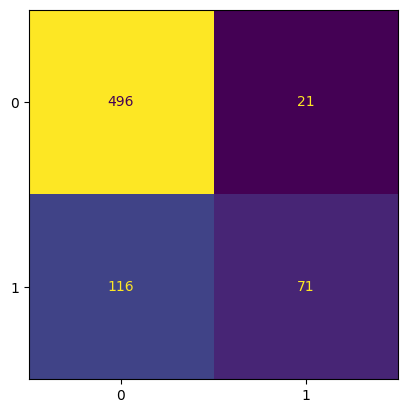

In [51]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 1)
estimate_quality(numpy.array(y_pred), y_test, ax = axes)

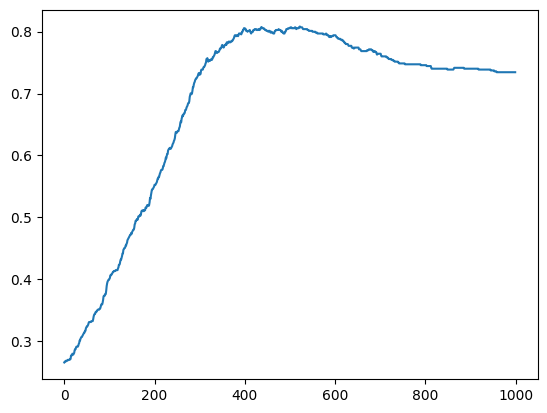

In [52]:
import sklearn.metrics

o = numpy.array(y_pred)
acc = []
for threshold in range(0, 1000):
    thr = threshold / 1000.
    u = o[:, 1] > thr
    acc.append(sklearn.metrics.accuracy_score(u, y_test))

plt.plot(list(range(0, 1000)), acc)

In [53]:
numpy.max(acc)

0.8082386363636364

In [13]:
import pandas as pd
from typing import List, Any
import joblib
class LazyClassifierFCA:
    def __init__(self):
        self.X_train = None
        self.y_train = None

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series) -> None:
        self.X_train = X_train
        self.y_train = y_train
        
    def classify_sample(self, sample: pd.Series) -> Any:
        # Split X_train into positive and negative classes
        X_train_positive = self.X_train[y_train == 1]
        X_train_negative = self.X_train[y_train == 0]
        
        positive_classifiers = 0
        negative_classifiers = 0

        # Split the each part into binary and numerical
        binary_X_train_positive = X_train_positive.select_dtypes(include='bool')
        numerical_X_train_positive = X_train_positive.select_dtypes(exclude='bool')
        binary_X_train_negative = X_train_negative.select_dtypes(include='bool')
        numerical_X_train_negative = X_train_negative.select_dtypes(exclude='bool')
        
        
        def find_number_of_positive_and_negative_matches(binary_intersection, numerical_intervals):
            # Binary condition: Matches the binary intersection
            binary_positive_match = (binary_X_train_positive | ~binary_intersection).all(axis=1)
            binary_negative_match = (binary_X_train_negative | ~binary_intersection).all(axis=1)
    
            # Numerical condition: Lies within the intervals
            numerical_positive_match = numerical_X_train_positive.apply(
                lambda row: all(
                    interval[0] <= value <= interval[1] for value, interval in zip(row, numerical_intervals)
                ),
                axis=1
            )
            numerical_negative_match = numerical_X_train_negative.apply(
                lambda row: all(
                    interval[0] <= value <= interval[1] for value, interval in zip(row, numerical_intervals)
                ),
                axis=1
            )
            # print(f"pos_supp: \n {list(X_train_positive[(binary_positive_match & numerical_positive_match)].index)}")
            # print(f"neg_supp: \n {list(X_train_negative[(binary_negative_match & numerical_negative_match)].index)}")
            # Combine binary and numerical conditions
            num_positive = (binary_positive_match & numerical_positive_match).sum()
            num_negative = (binary_negative_match & numerical_negative_match).sum()
            return num_positive, num_negative
        
        # Function to check if intersection with a train sample is a positive classifier
        def is_positive_classifier(binary_intersection, numerical_intervals):
            num_positive, num_negative = find_number_of_positive_and_negative_matches(binary_intersection, numerical_intervals)
            return num_negative == 0 and num_positive > 1
        
        # Function to check if intersection is a negative classifier
        def is_negative_classifier(binary_intersection, numerical_intervals):
            num_positive, num_negative = find_number_of_positive_and_negative_matches(binary_intersection, numerical_intervals)
            return num_positive == 0 and num_negative > 1
        
        # Check for positive classifiers by intersecting sample with each positive object
        for _, pos_sample in X_train_positive.iterrows():
            # Binary intersection: AND operation
            binary_intersection = sample[binary_X_train_positive.columns] & pos_sample[binary_X_train_positive.columns]
            
            # Numerical intersection: Interval
            numerical_intersection = [
                (min(sample[col], pos_sample[col]), max(sample[col], pos_sample[col]))
                for col in numerical_X_train_positive.columns
            ]
            # print({sample.name}, {pos_sample.name})
            # print(f"{sample=}")
            # print(f"{pos_sample=}")
            # print(f"{binary_intersection=} \n {numerical_intersection=}")
            
            # Combine intersections and check
            if is_positive_classifier(binary_intersection, numerical_intersection):
                positive_classifiers += 1
        
        # Check for negative classifiers by intersecting sample with each negative object
        for _, neg_sample in X_train_negative.iterrows():
            # Binary intersection: AND operation
            binary_intersection = sample[binary_X_train_negative.columns] & neg_sample[binary_X_train_negative.columns]
            
            # Numerical intersection: Interval
            numerical_intersection = [
                (min(sample[col], neg_sample[col]), max(sample[col], neg_sample[col]))
                for col in numerical_X_train_negative.columns
            ]
            
            # Combine intersections and check
            if is_negative_classifier(binary_intersection, numerical_intersection):
                negative_classifiers += 1

        # Determine the class based on the number of classifiers
        if positive_classifiers > negative_classifiers:
            # print(f"sample {sample.name} is classified as 1, {positive_classifiers}, {negative_classifiers}")
            return 1  # Predict positive
            
        elif negative_classifiers > positive_classifiers:
            # print(f"sample {sample.name} is classified as 0, {positive_classifiers}, {negative_classifiers}")
            return 0  # Predict negative

        else:
            # If equal, you can decide on a rule, like defaulting to 0 or 1, or returning 'undetermined'
            # print(f"sample {sample.name} is classified as 1, default, {positive_classifiers}, {negative_classifiers}")
        
            return 1  # or 0, depending on the choice


    def predict(self, X_test: pd.DataFrame) -> List[Any]:
        # List to store predictions for each test sample
        predictions = []
        
        def do(sample):
            return self.classify_sample(sample)
        
        import tqdm

        par = joblib.Parallel(n_jobs = -1)(
            joblib.delayed(do)(sample)
            for _, sample in tqdm.tqdm(X_test.iterrows(), total = len(X_test))
        )
        
        return par

In [9]:
qq = pd.DataFrame(X_train)
qq2 = pd.DataFrame(X_test)
for column in qq.columns:
    if len(qq[column].unique()) == 2:
        qq[column] = qq[column].astype(bool)
        qq2[column] = qq2[column].astype(bool)

In [14]:
fca = LazyClassifierFCA()
fca.fit(qq, y_train)
fca.predict(qq2)

  3%|▎         | 24/704 [00:56<31:11,  2.75s/it]

KeyboardInterrupt: 